# Regression & Regularization

-------------------------------------------------------

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

### What is Regularization ?
Machine Learning Regularization is a technique used in machine learning to reduce overfitting by adding a penalty term to the loss function, encouraging the model to learn simpler patterns instead of memorizing the training data.


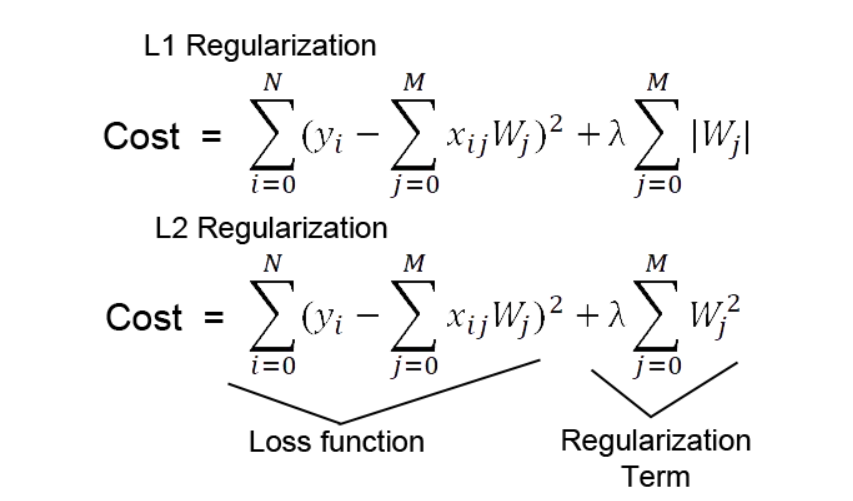

# Ridge Regression (L2)

The rigde regularizaion is done to reduce the sensitivity towards of highly correlated features. It shrinks the weights of uneccessary features towards zero, but never zero.

This prevents the model from overfitting



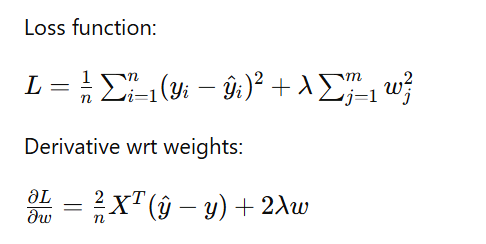

In [143]:
class RidgeRegression():
    # Setting up hyper-parameters
    def __init__ (self, l_r=.01, epochs=1000, alpha=0.1):
        self.l_r = l_r
        self.epochs = epochs
        self.alpha = alpha

    def fit(self, X, y):
        err = np.array([])
        w_l = np.array([])

        # initializing weights and bias of correct dimensions
        length = X.shape[0]
        w = np.random.randn(y.shape[1], X.shape[1])
        b = np.zeros((1, y.shape[1]))

        # training loop
        for step in range(self.epochs):

            # calculating the weighted sum
            y_p = X @ w.T + b

            #expression for the Mean Squared Error + Penalty Term
            J = np.sum((y_p - y)**2)/(length) + self.alpha * np.sum(w**2)

            # calculating derivatives - to find gradients of Weights and Bias

                                                            #---->| This is the derivative of penalty term wrt w
            dL_dw = (-2 * (X.T @ (y - y_p)) / length) + 2 * self.alpha * w.T

            dL_db = np.sum(-2 * (y - y_p), axis=0, keepdims=True) / (length)

            # Performing gradient descent update step

            # Iteratively we're finding the minima of the Loss Function (J)
            w -= dL_dw.T * self.l_r
            b -= dL_db * self.l_r

            w_l = np.append(w_l, w[0, 0])
            err= np.append(err, J)

        # updating the optimized weights and bias
        self.w = w
        self.b = b
        return w_l, err

    # Performing linear Regression
    def predict(self, x):
        return ( x @ self.w.T ) + self.b

    # this is R2 score  -  total variance explained by the model
    def accuracy(self, y, ycap):
        rss = np.sum((y - ycap) ** 2)
        tot_var = np.sum((y - np.mean(y)) ** 2)

        r2 = 1 - (rss / tot_var)
        return r2



# Lasso Regression (L1)

Uses L1 Regularization. It could perform automatic feature selection by making the weights of highly correlated features or features which doesnt affect the predeiction to zero.

Prevents overfitting

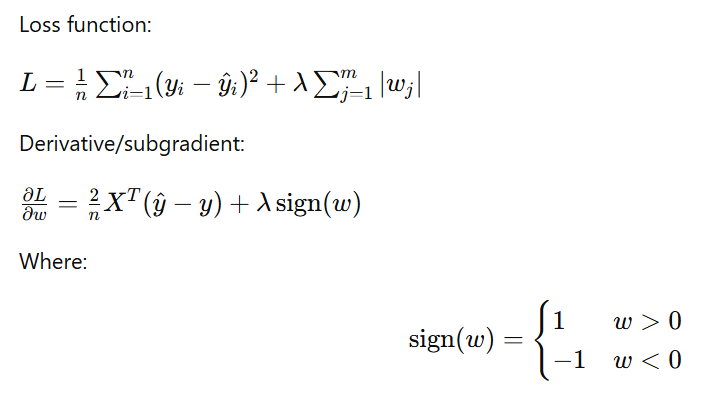

In [144]:
# every thing is same except the derivative of penalty term
class LassoRegression():
    def __init__ (self, l_r=.01, epochs=1000, alpha=0.1):
        self.l_r = l_r
        self.epochs = epochs
        self.alpha = alpha

    def fit(self, X, y):
        err = []
        w_l = []
        length = X.shape[0]
        w = np.random.randn(y.shape[1], X.shape[1])
        b = np.zeros((1, y.shape[1]))
        for step in range(self.epochs):
            y_p = X @ w.T + b
            J = np.sum((y_p - y)**2)/(length) + self.alpha * np.sum(np.abs(w)) # we just changed here
                                                                #---> derivative of the penalty term lambda |w|

            dL_dw = -2 * ((X.T) @ (y - (X @ w.T + b))) / (length) + self.alpha * np.sign(w.T) # we just changed here
            dL_db = np.sum(-2 * (y - (X @ w.T + b))) / (length)

            w -= dL_dw.T * self.l_r
            b -= dL_db * self.l_r

            w_l.append(w[0,0])
            err.append(J)
        self.w = w
        self.b = b
        return w_l, err

    def predict(self, x):
        return ( x @ self.w.T ) + self.b

    def accuracy(self, y, ycap):
        rss = np.sum((y - ycap) ** 2)
        tot_var = np.sum((y - np.mean(y)) ** 2)

        r2 = 1 - (rss / tot_var)
        return r2

In [24]:
dat = datasets.fetch_california_housing()
train_data = 0.8

X = dat.data
y = dat.target

indices = np.random.permutation(X.shape[0])
index_train = int(X.shape[0] * train_data)

# performing test train split
X_train = X[indices[:index_train]]
y_train = y[indices[:index_train]]
X_test = X[indices[index_train:]]
y_test = y[indices[index_train:]]

X_train = X_train.reshape(-1, 8)
y_train = y_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 8)

# normalizing data
# I normalized to avoid unstable gradients or gradient explosion (gradients become too large and loss reaches NaN)
# here all the features are scaled such that their mean = 0 and variance = 1
X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
X_test = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)

print(X_train[0])
print(y_train[0])

[ 0.18151148  1.29791691 -0.1316106  -0.12384619  0.13255838  0.01980945
 -0.70425351  0.69168461]
[1.679]


R2 score of Ridge 0.6298915280953441
Weights for the first feature 0.8091406639146093


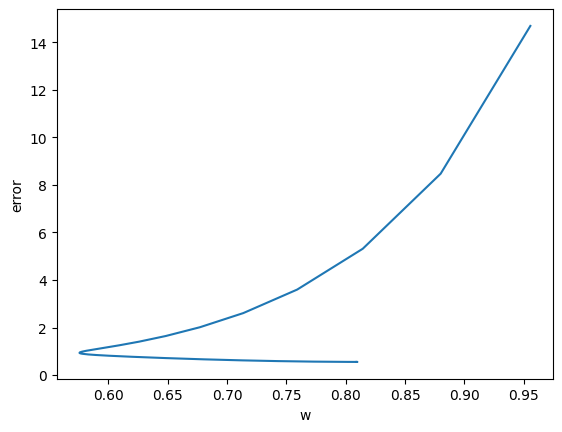

In [154]:
model_Ridge = RidgeRegression(0.1, 1000, 0.01)
w_l, err = model_Ridge.fit(X_train, y_train)

y_pred = model_Ridge.predict(X_test)
print("R2 score of Ridge", model_Ridge.accuracy(y_test, y_pred))
print("Weights for the first feature" , w_l[-1])

# I selected weights of first feature to show the convergence
plt.plot(w_l, err)
plt.xlabel('w')
plt.ylabel('error')
plt.show()


R2 score of Lasso 0.6302721596041817
Weights for the first feature 0.813297392443556


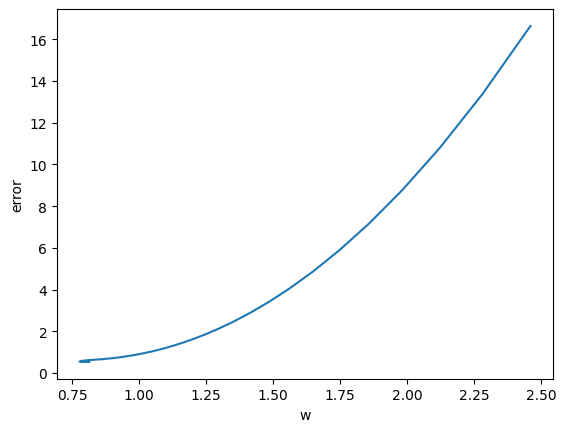

In [155]:
model_Lasso = LassoRegression(0.05, 1000, 0.0001)
w, l = model_Lasso.fit(X_train, y_train)

y_pred = model_Lasso.predict(X_test)
print("R2 score of Lasso", model_Lasso.accuracy(y_test, y_pred))
print("Weights for the first feature" , w[-1])

plt.plot(w, l)
plt.xlabel('w')
plt.ylabel('error')
plt.show()

#Comparing how each regularization method affects the model weights and overall accuracy

### We could see the cost function is minimized by optimizing the weights in both cases

### We could observe that the weight corresponding to the first feature turned out to be **very close** in both lasso and ridge